In [1]:
#chạy đống này trong terminal vào lần đầu tiên:
#pip install Tensorflow
#hơi lâu, chạy xong rồi bấm chạy ô code này là sẽ ngon lành

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
df2 = pd.read_csv("../dataset/test.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [3]:
#build mô hình
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
#output nhị phân thì ló phải ntn
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
#kệ cái warning nhá ksao đâu

In [ ]:
#ok nói trước là cell này chạy hơi lâu, tầm hơn chục giây
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("int32")
y_test = y_test.astype("int32")
#ok huấn luyện nè
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

#test
y_pred = (model.predict(X_test) > 0.5).astype("int32")

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7486 - loss: 0.5467 - val_accuracy: 0.7669 - val_loss: 0.4987
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7657 - loss: 0.5030 - val_accuracy: 0.7647 - val_loss: 0.4805
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7714 - loss: 0.4880 - val_accuracy: 0.8095 - val_loss: 0.5041
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7726 - loss: 0.4804 - val_accuracy: 0.7882 - val_loss: 0.4606
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7796 - loss: 0.4798 - val_accuracy: 0.7960 - val_loss: 0.4329
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7808 - loss: 0.4719 - val_accuracy: 0.8067 - val_loss: 0.4349
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7781 - loss: 0.4730 - val_accuracy: 0.7982 - val_loss: 0.4330
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7810 - loss: 0.4686 - val_accuracy: 0.

Original DNN Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88      1033
           1       0.71      0.47      0.56       374

    accuracy                           0.81      1407
   macro avg       0.77      0.70      0.72      1407
weighted avg       0.80      0.81      0.79      1407



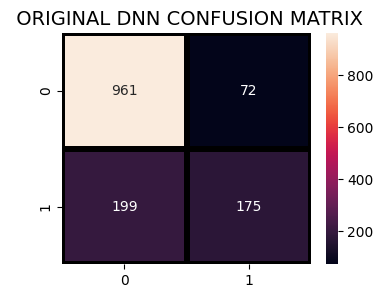

In [ ]:
print("Original DNN Report:\n", (classification_report(y_test, y_pred)))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" ORIGINAL DNN CONFUSION MATRIX",fontsize=14)
plt.show()

In [8]:
#cách nâng cấp #1: Thêm class weight
from sklearn.utils import class_weight
#coi y_train là vector nhãn (0 = non-churn, 1 = churn)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
#convert thành dạng dict cho kẹo rau hiểu
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

#nấu lại nè, thêm đúng cái dòng class weight thôi
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, class_weight=class_weights_dict, verbose=1)
y_pred_weight = (model.predict(X_test) > 0.5).astype("int32")

{0: np.float64(0.6809927360774818), 1: np.float64(1.8812709030100334)}
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7349 - loss: 0.5169 - val_accuracy: 0.7633 - val_loss: 0.4400
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7477 - loss: 0.5128 - val_accuracy: 0.7335 - val_loss: 0.4851
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7403 - loss: 0.5108 - val_accuracy: 0.7790 - val_loss: 0.4475
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7397 - loss: 0.5119 - val_accuracy: 0.7491 - val_loss: 0.4645
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7339 - loss: 0.5141 - val_accuracy: 0.7441 - val_loss: 0.4695
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7426 - loss: 0.5128 - val_accuracy: 0.7740 - val_loss: 0.4397
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7378 - loss: 0.5093 - val_accuracy: 0.7129 - val_loss: 0.5125
Epoch 8/50
176/176 ━━━━━━━━━━━━━━

Class Weighed DNN Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      1033
           1       0.49      0.87      0.63       374

    accuracy                           0.72      1407
   macro avg       0.71      0.77      0.70      1407
weighted avg       0.82      0.72      0.74      1407



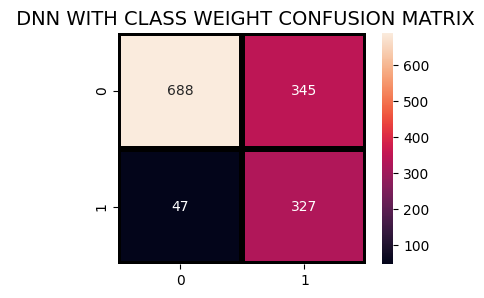

In [10]:
#kq nè
print("Class Weighed DNN Report:")
print(classification_report(y_test, y_pred_weight))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_weight), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" DNN WITH CLASS WEIGHT CONFUSION MATRIX",fontsize=14)
plt.show()

In [11]:
#can thiệp vào kiến trúc mô hình (tăng số tầng ẩn, thêm dropout và batch normalization)
#đây xây lại mô hình nè
#Input layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
#Hidden layers: tăng số tầng và drop out 3-4
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
#Output layer
model.add(Dense(1, activation='sigmoid'))
#Compile nè
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

#ok giờ train thui (vẫn giữ weight nhá)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, class_weight=class_weights_dict, verbose=1)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6916 - loss: 0.6084 - val_accuracy: 0.7875 - val_loss: 0.6005
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7100 - loss: 0.5702 - val_accuracy: 0.6915 - val_loss: 0.6194
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7099 - loss: 0.5463 - val_accuracy: 0.7854 - val_loss: 0.5067
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7141 - loss: 0.5405 - val_accuracy: 0.7427 - val_loss: 0.4930
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7243 - loss: 0.5455 - val_accuracy: 0.7619 - val_loss: 0.4719
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7292 - loss: 0.5341 - val_accuracy: 0.7171 - val_loss: 0.4962
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7227 - loss: 0.5359 - val_accuracy: 0.6745 - val_loss: 0.5438
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7278 - loss: 0.5386 - val_accu

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
DNN With New Model Structure Report:
               precision    recall  f1-score   support

           0       0.94      0.61      0.74      1033
           1       0.45      0.90      0.60       374

    accuracy                           0.69      1407
   macro avg       0.70      0.75      0.67      1407
weighted avg       0.81      0.69      0.70      1407



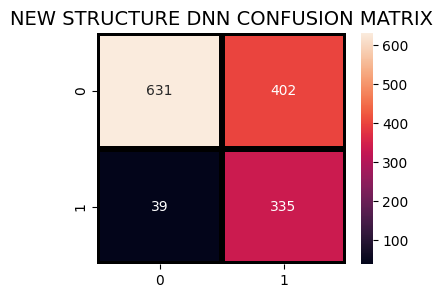

In [12]:
#test nè
y_pred_struc = (model.predict(X_test) > 0.5).astype("int32")

print("DNN With New Model Structure Report:\n", (classification_report(y_test, y_pred_struc)))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_struc), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("NEW STRUCTURE DNN CONFUSION MATRIX",fontsize=14)
plt.show()

In [13]:
#threshold tuning
y_pred_proba = model.predict(X_test)
best_f1 = 0
best_threshold = 0.5
#thử liên từ 0.2 đến 0.8
for t in [i/100 for i in range(20, 81, 5)]:
    y_pred = (y_pred_proba > t).astype("int32")
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
print("Best threshold:", best_threshold, "with F1:", best_f1)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step
Best threshold: 0.6 with F1: 0.6274509803921569


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step
Classification Report (Threshold = 0.6274):
DNN With New Threshold Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.69      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



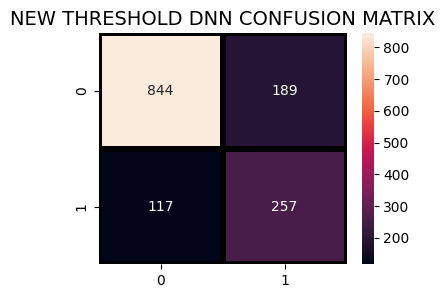

In [16]:
#được r nấu lại bằng threshold trên nhé
y_pred_proba = model.predict(X_test)
best_threshold = 0.62745
y_pred_opt = (y_pred_proba > best_threshold).astype("int32")
#cook lại model
print("Classification Report (Threshold = {:.4f}):".format(best_threshold))

print("DNN With New Threshold Report:\n", (classification_report(y_test, y_pred_opt)))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("NEW THRESHOLD DNN CONFUSION MATRIX",fontsize=14)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step
2-Layer DNN Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1033
           1       0.69      0.52      0.59       374

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.73      1407
weighted avg       0.80      0.81      0.80      1407



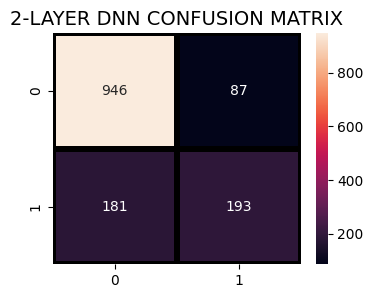

In [21]:
#ok nhai lại con hàng trên làm layer 1 nè
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.62745).astype("int32")

#lọc ra các kh bị dự đoán là churn
churn_candidates = X_test[y_pred_dnn.flatten() == 1]

#layer 2 thì đi rừng (dùng kq 500 cây và depth 10 như file rừng)
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(churn_candidates).flatten()

#kq cuối cùng sẽ giữ lại những churn được duyệt bởi rừng thôi
final_predictions = y_pred_dnn.copy()
final_predictions[y_pred_dnn == 1] = y_pred_rf

#oánh giá
print("2-Layer DNN Report:\n", (classification_report(y_test, final_predictions)))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("2-LAYER DNN CONFUSION MATRIX",fontsize=14)
plt.show()

In [26]:
#nốt cái bảng này để đi ngủ !
data = {
    "Model": [
        "Original DNN",
        "DNN + class weight",
        "DNN with new structure",
        "DNN threshold 0.6274",
        "2-layer DNN + RF"
    ],
    "Accuracy": [0.81, 0.72, 0.69, 0.78, 0.77],
    "Precision_churn": [0.71, 0.49, 0.45, 0.58, 0.69],
    "Recall_churn": [0.47, 0.87, 0.90, 0.69, 0.52],
    "F1_churn": [0.56, 0.63, 0.60, 0.63, 0.59],
}

df = pd.DataFrame(data)
print(df)

                    Model  Accuracy  Precision_churn  Recall_churn  F1_churn
0            Original DNN      0.81             0.71          0.47      0.56
1      DNN + class weight      0.72             0.49          0.87      0.63
2  DNN with new structure      0.69             0.45          0.90      0.60
3    DNN threshold 0.6274      0.78             0.58          0.69      0.63
4        2-layer DNN + RF      0.77             0.69          0.52      0.59


In [1]:
#bảng này thì không tính hybrid. nhỏ hybrid sang bên kia chơi
import pandas as pd

data = {
    "Model": [
        "DNN (original)",
        "DNN (class weight)",
        "DNN (new structure)",
        "DNN (new threshold)"
    ],
    "Accuracy": [0.81, 0.72, 0.69, 0.78],
    "Precision_churn": [0.71, 0.49, 0.45, 0.58],
    "Recall_churn": [0.47, 0.87, 0.90, 0.69],
    "F1_churn": [0.56, 0.63, 0.60, 0.63]
}
df = pd.DataFrame(data)

print(df.to_string(index=False))

              Model  Accuracy  Precision_churn  Recall_churn  F1_churn
     DNN (original)      0.81             0.71          0.47      0.56
 DNN (class weight)      0.72             0.49          0.87      0.63
DNN (new structure)      0.69             0.45          0.90      0.60
DNN (new threshold)      0.78             0.58          0.69      0.63
